# PCG — Dungeon 2D + agente avaliador (Gerar-e-Testar)

**Disciplina:** Inteligência Artificial para Jogos (Geração Procedural)  
**Componentes:** (1) *Construtor* — `dungeon_pcg.py` · (2) *Crítico* — BFS em espaço de estados · (3) *Visualização* — sprites 48×48 (tiles 16×16).

Este notebook serve para **reproduzir** a geração, **inspecionar parâmetros** e **exportar** mapas aprovados. O código completo está no módulo Python (avaliação linha-a-linha recomendada no IDE).

**Logo abaixo** há duas secções teóricas — **como o mapa é gerado** (construtivo) e **como é testado** (gerar-e-testar + escolha de busca) — pensadas para **documentação de entrega** em IA para Jogos.

## Como o mapa é gerado (Geração construtiva — Etapa 1)

O gerador **não** pinta pixels aleatoriamente: segue um **pipeline lógico** em camadas. Cada passo aplica *constraints*; se alguma falha, `build_dungeon` devolve `None` e o laço **gerar-e-testar** tenta outro candidato (novo consumo do RNG).

### 1.1 Colocação de salas
- Sorteam-se **N** retângulos (`Room`) dentro da grelha, com **margem** entre si (sem sobreposição).
- Cada sala preenche o seu retângulo com `Terrain.FLOOR`.

### 1.2 Topologia em árvore (macro)
- Constrói-se uma **árvore aleatória** sobre os índices das salas: para cada `j = 1..N-1`, liga-se a sala `j` a uma sala `i < j` escolhida ao acaso. Isto garante **uma única rota** entre salas ao nível do **grafo de salas** (sem ciclos entre salas).

### 1.3 Corredores (1 célula de largura)
- Para cada aresta `(i, j)` da árvore, calcula-se um caminho em **L** (Manhattan em dois segmentos) entre os **centros** das salas `i` e `j`.
- A união dos retângulos das salas com todos os caminhos define o conjunto **`floor_cells`**. Células do caminho que **não** pertencem a nenhum interior de sala são classificadas como **`corridor_cells`** — é aqui que podem nascer **monstros** (força confronto no corredor).

### 1.4 Portas e cofres (design por árvore)
- **Uma porta por aresta**: para cada aresta `(pai, filho)`, coloca-se uma célula `Terrain.DOOR` numa posição de **corredor** tangente à **sala filha** (entrada “canónica” dessa sala no modelo).
- **Tesouros** apenas no centro (aproximado) de **salas-folha** (grau 1 na árvore).
- **Verificação de brecha** (`_leaf_single_door_exit`): para cada folha com tesouro, todas as células `FLOOR`/`DOOR` fora do retângulo que tocam o interior têm de coincidir **exactamente** com a **única** porta — senão haveria entrada sem chave.

### 1.5 Itens e economia
- **Chaves:** pelo menos tantas chaves quantas portas; **nunca** no interior de salas-folha (evita chave inacessível atrás da própria porta).
- **Poções:** pelo menos **M** para **M** monstros, por causa da regra **`may_fight`** (ver secção seguinte).
- **Início / saída:** preferencialmente em salas **não-folha** para reduzir degenerescências.

### 1.6 Parede vs. “fundo” visual (não andável)
- Inicialmente tudo fora do piso é `WALL`.
- `_mark_exterior_void` converte em `Terrain.VOID` as células “parede” que **não** são vizinhas de `FLOOR`/`DOOR` — é a **massa exterior** do mapa.
- Na folha de sprites: **parede do limiar** = tile `(0,0)`; **VOID** = **3.º tile da 1.ª linha** `(2,0)`; **piso** = `(2,2)`.

---



## Como o mapa é testado (Gerar-e-testar + busca — Etapa 2)

### 2.1 Metodologia *Gerar-e-Testar* (Search-Based PCG)
1. **Gerar:** `build_dungeon(rng, …)` produz um **candidato** (grelha + entidades + portas).
2. **Testar:** `validate_dungeon` pergunta: *existe uma política de movimento legal que cumpra o completionist?*
3. Se **não**, descarta-se o candidato e repete-se com o mesmo RNG a avançar (nova tentativa).
4. Se **sim**, o mapa é **aprovado** e pode ser renderizado (Etapa 3).

Isto implementa **PCG baseada em busca** no sentido da literatura/aula: o conteúdo só “entra na entrega” depois de passar num **solver** que encarna as regras de jogo.

### 2.2 O “agente” é uma busca em grafo de estados
O herói não é uma IA opaca: é um **modelo explícito** de jogo **discreto**. O estado não é só `(x, y)` — inclui inventário lógico e progresso:

| Dimensão | Porquê |
|----------|--------|
| Posição `(x,y)` | Movimento 4-vizinhança. |
| `hp` (1/0) | Saudável vs. ferido; segundo monstro consecutivo sem cura = morte. |
| Máscaras (`monsters_alive`, `treasures`, `doors_open`, `keys_taken`, `potions_taken`) | Itens/chaves/portas são **consumíveis** ou **persistentes**; o solver tem de memorizar o que já aconteceu. |
| `may_fight` | Regra pedida: **é obrigatório consumir uma poção antes de cada combate** (incluindo o 1.º monstro). Sem este bit, o espaço de estados admite atalhos inválidos conceptualmente. |

Chaves no inventário são **deriváveis** de `popcount(keys_taken) − popcount(doors_open)` (cada abertura gasta uma chave).

### 2.3 Qual algoritmo de busca e porquê **BFS**
Considerámos o problema como **exploração de um grafo implícito** onde cada arco é uma **acção** (mover para cima/baixo/esquerda/direita) com custo uniforme **1** por passo de simulação.

| Algoritmo | Adequação aqui |
|-----------|------------------|
| **BFS (largura)** | **Completo** num espaço finito: se existe solução, BFS encontra (até ao limite de estados visitados). Com custo uniforme, coincide com **UCS**. É o mais simples de implementar corretamente com `visited` em conjunto de estados. |
| **DFS** | Também completo com `visited`, mas tende a **profundizar** primeiro; sem limite de profundidade pode atrasar a descoberta de soluções “rasas” e, na prática, pior comportamento com orçamento de expansões. |
| **A-estrela** | Requer **heurística admissível** para o vector de estados (portas, máscaras, `may_fight`). Uma heurística só geométrica (distância à saída) **ignora** economia de chaves/poções e é **inadmissível** — arrisca-se a cortar soluções válidas. |
| **IDA / feixe (*beam*)** | Úteis para memória, mas acrescentam complexidade sem ganho claro dado que já limitámos monstros/portas para manter o ramo finito. |

**Conclusão para o relatório:** escolhemos **BFS em largura** como **solver de validação** porque o grafo de estados é **não ponderado** (ou ponderado uniformemente), o espaço é **discreto e finito** (com tectos práticos), e queremos **correção + reprodutibilidade** antes de optimizar tempo.

### 2.4 Complexidade e salvaguardas
- O pior caso é **exponencial** no número de entidades com máscaras (exploração tipo produto cartesiano).
- No código: **tectos** em contagens (ex.: monstros) e **`max_states`** na BFS evitam travas infinitas se o candidato for “cruel” para o solver.

### 2.5 Critério de aprovação (função de *fitness* binária)
O mapa só é válido se existir estado final na saída com:
- todos os **tesouros** colectados,
- todos os **monstros** mortos,
- todas as **portas** abertas,
- e **sem morte** do herói ao longo do caminho encontrado.

---



## Referência rápida — tabela (para o professor)

| Etapa | O quê | Onde no código |
|--------|--------|----------------|
| **Construtor** | Salas retangulares + corredor em L (1 célula); grafo de salas é **árvore**; **uma porta por aresta** da árvore (célula de corredor junto à **sala filha** — sem entrar na sala sem chave); **tesouro só em sala-folha**; **monstro só em corredor**; folhas com tesouro **sem brechas** (só a porta liga o interior ao resto do mapa). | `build_dungeon`, `_leaf_single_door_exit` |
| **Crítico** | **Gerar-e-testar**; **BFS** com estado que inclui **`may_fight`**: é **obrigatório consumir uma poção no chão antes de cada combate** com monstro (incluindo o 1.º); `build_dungeon` garante **≥ M poções** para **M** monstros; completionist (tesouros, monstros, portas). | `generate_until_valid`, `validate_dungeon`, `SearchState` |
| **Show** | Na folha `PCG-sprites-dungeon.png` (grelha 3×3 de 16×16): **1.º tile da 1.ª linha** `(0,0)` = **parede** do limiar; **3.º tile da 1.ª linha** `(2,0)` = **`Terrain.VOID`** = **fundo / preenchimento não andável** (massa fora do labirinto, após `_mark_exterior_void`); **último tile** `(2,2)` = **piso** andável; início/saída com brilho. | `load_sprites` (`"void"` ↔ crop `(2,0)`), `_mark_exterior_void`, `render_map` |

### Regras pedidas (resumo para o professor)

1. **Poção antes de cada monstro:** o agente só pode entrar num monstro **vivo** se `may_fight=1`; consumir uma poção nova põe `may_fight=1`; matar monstro põe `may_fight=0`.
2. **Salas fechadas por porta / sem brecha:** uma porta por aresta da árvore; em cada **folha** com tesouro, todas as saídas (vizinho FLOOR/DOOR fora do retângulo) têm de ser **só** a célula da porta.
3. **Chaves:** uma chave por porta no mínimo; **nunca** no interior de salas-folha.
4. **Fundo não andável = 3.º tile da 1.ª linha:** células `VOID` usam o recorte `sprites["void"]` = coluna **2**, linha **0** (terceiro quadradinho da primeira fila da folha).

**Sprites:** `assets/PCG-sprites-dungeon.png` (obrigatório na pasta do projeto).

## 2. Parâmetros

- **Mapa demo (igual à CLI):** usa `pcg.DEMO_GENERATE_KWARGS` e `pcg.generate_demo_map()` — não alteres isso se quiseres o mesmo PNG que `python3 dungeon_pcg.py`.
- **Segundo mapa:** `CONFIG_EXTRA` na célula de código (semente e `max_tries` só para essa geração).

| Chave em `DEMO_GENERATE_KWARGS` | Valor |
|--------------------------------|-------|
| seed | 14 |
| max_tries | 200 |
| width, height, n_rooms | 48, 40, 5 |

`monster_density` não é passado (fica o default **0.12** em `build_dungeon`).


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "dungeon_pcg.py").is_file():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import dungeon_pcg as pcg

# Parâmetros extra (2.º mapa). O mapa IGUAL à demo da CLI usa só pcg.DEMO_GENERATE_KWARGS.
CONFIG_EXTRA = {
    "seed_segundo_mapa": 22,
    "max_tries_segundo": 200,
}

SPRITES = ROOT / "assets" / "PCG-sprites-dungeon.png"
assert SPRITES.is_file(), f"Falta: {SPRITES}"

sprites = pcg.load_sprites(SPRITES)
print("Módulo:", pcg.__file__)
print("Demo (idêntica à CLI):", pcg.DEMO_GENERATE_KWARGS)
print("Extra:", CONFIG_EXTRA)


Módulo: /home/deriki/dev/jogos v1/dungeon_pcg.py
Demo (idêntica à CLI): {'seed': 14, 'max_tries': 200, 'width': 48, 'height': 40, 'n_rooms': 5}
Extra: {'seed_segundo_mapa': 22, 'max_tries_segundo': 200}


## 3. Gerar mapa **aprovado** e exportar PNG

A função `generate_until_valid` chama `build_dungeon` até `validate_dungeon` devolver sucesso: **BFS** até à saída com **todos os tesouros**, **monstros mortos**, **portas abertas**, e a regra **`may_fight`** (obrigatório **consumir uma poção antes de cada combate**, incluindo o primeiro monstro).

### Métricas — mapa demo (reprodutível)

Dimensões: 48x40
Salas-folha (tesouros+portas): 3
Portas: 4 | Chaves colocadas: 4
Monstros (só corredor): 5 | Poções: 6
Início (24, 13) | Saída (17, 18)
Passos (estados): 217


**PNG:** `mapa_notebook_eval.png` e **`mapa_aprovado_demo.png`** (este último sobrescrito = mesma imagem que a CLI).

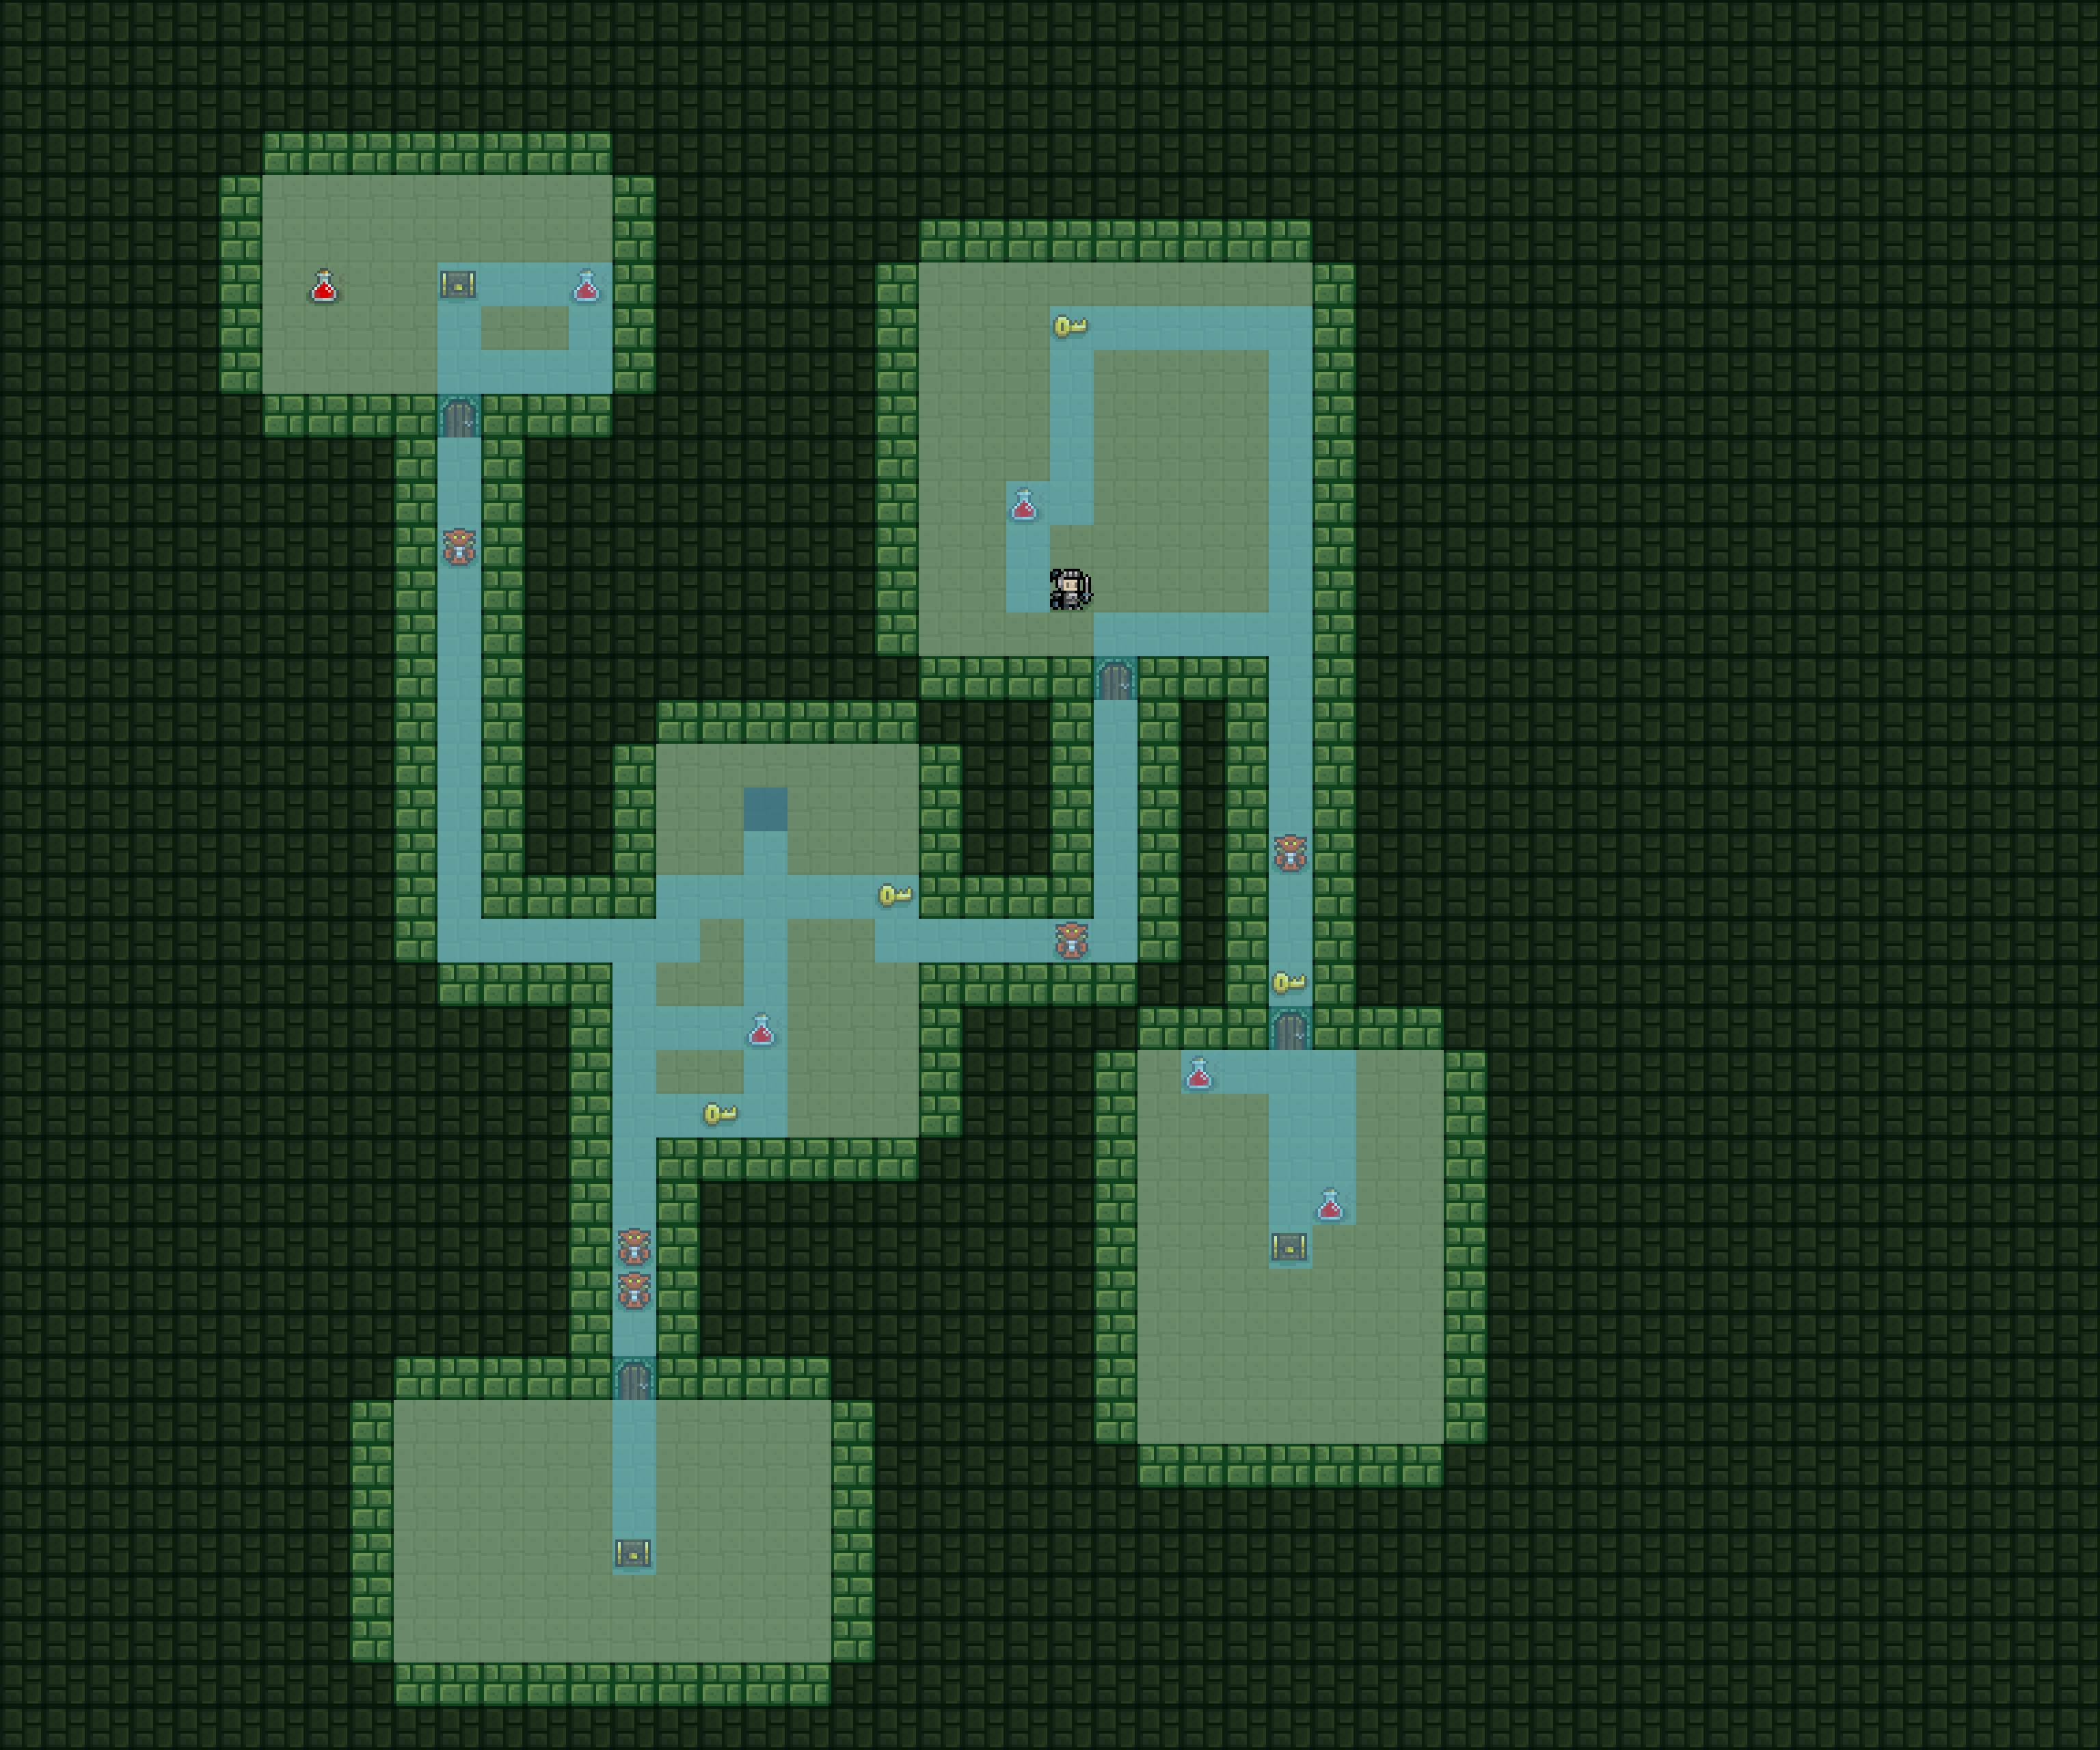

In [2]:
from IPython.display import display, Markdown, Image as IPyImage

# === Mapa 1: EXACTAMENTE o mesmo que `python3 dungeon_pcg.py` (assets/mapa_aprovado_demo.png) ===
dm, caminho = pcg.generate_demo_map()

display(Markdown("### Métricas — mapa demo (reprodutível)"))
print(pcg.summarize(dm))
print(f"Passos (estados): {len(caminho)}")

img = pcg.render_map(dm, sprites, path_overlay=caminho, scale=4)
out_eval = ROOT / "assets" / "mapa_notebook_eval.png"
img.save(out_eval)
out_demo = ROOT / "assets" / "mapa_aprovado_demo.png"
img.save(out_demo)
display(Markdown(f"**PNG:** `{out_eval.name}` e **`{out_demo.name}`** (este último sobrescrito = mesma imagem que a CLI)."))
display(IPyImage(filename=str(out_eval)))


## 4. Segundo exemplo (outra semente)

Altera `CONFIG_EXTRA` na primeira célula de código (`seed_segundo_mapa`, `max_tries_segundo`).

Seed 2: 22
Dimensões: 48x40
Salas-folha (tesouros+portas): 2
Portas: 4 | Chaves colocadas: 4
Monstros (só corredor): 6 | Poções: 8
Início (29, 27) | Saída (40, 37) 
Passos: 214


**PNG:** `mapa_notebook_extra.png`

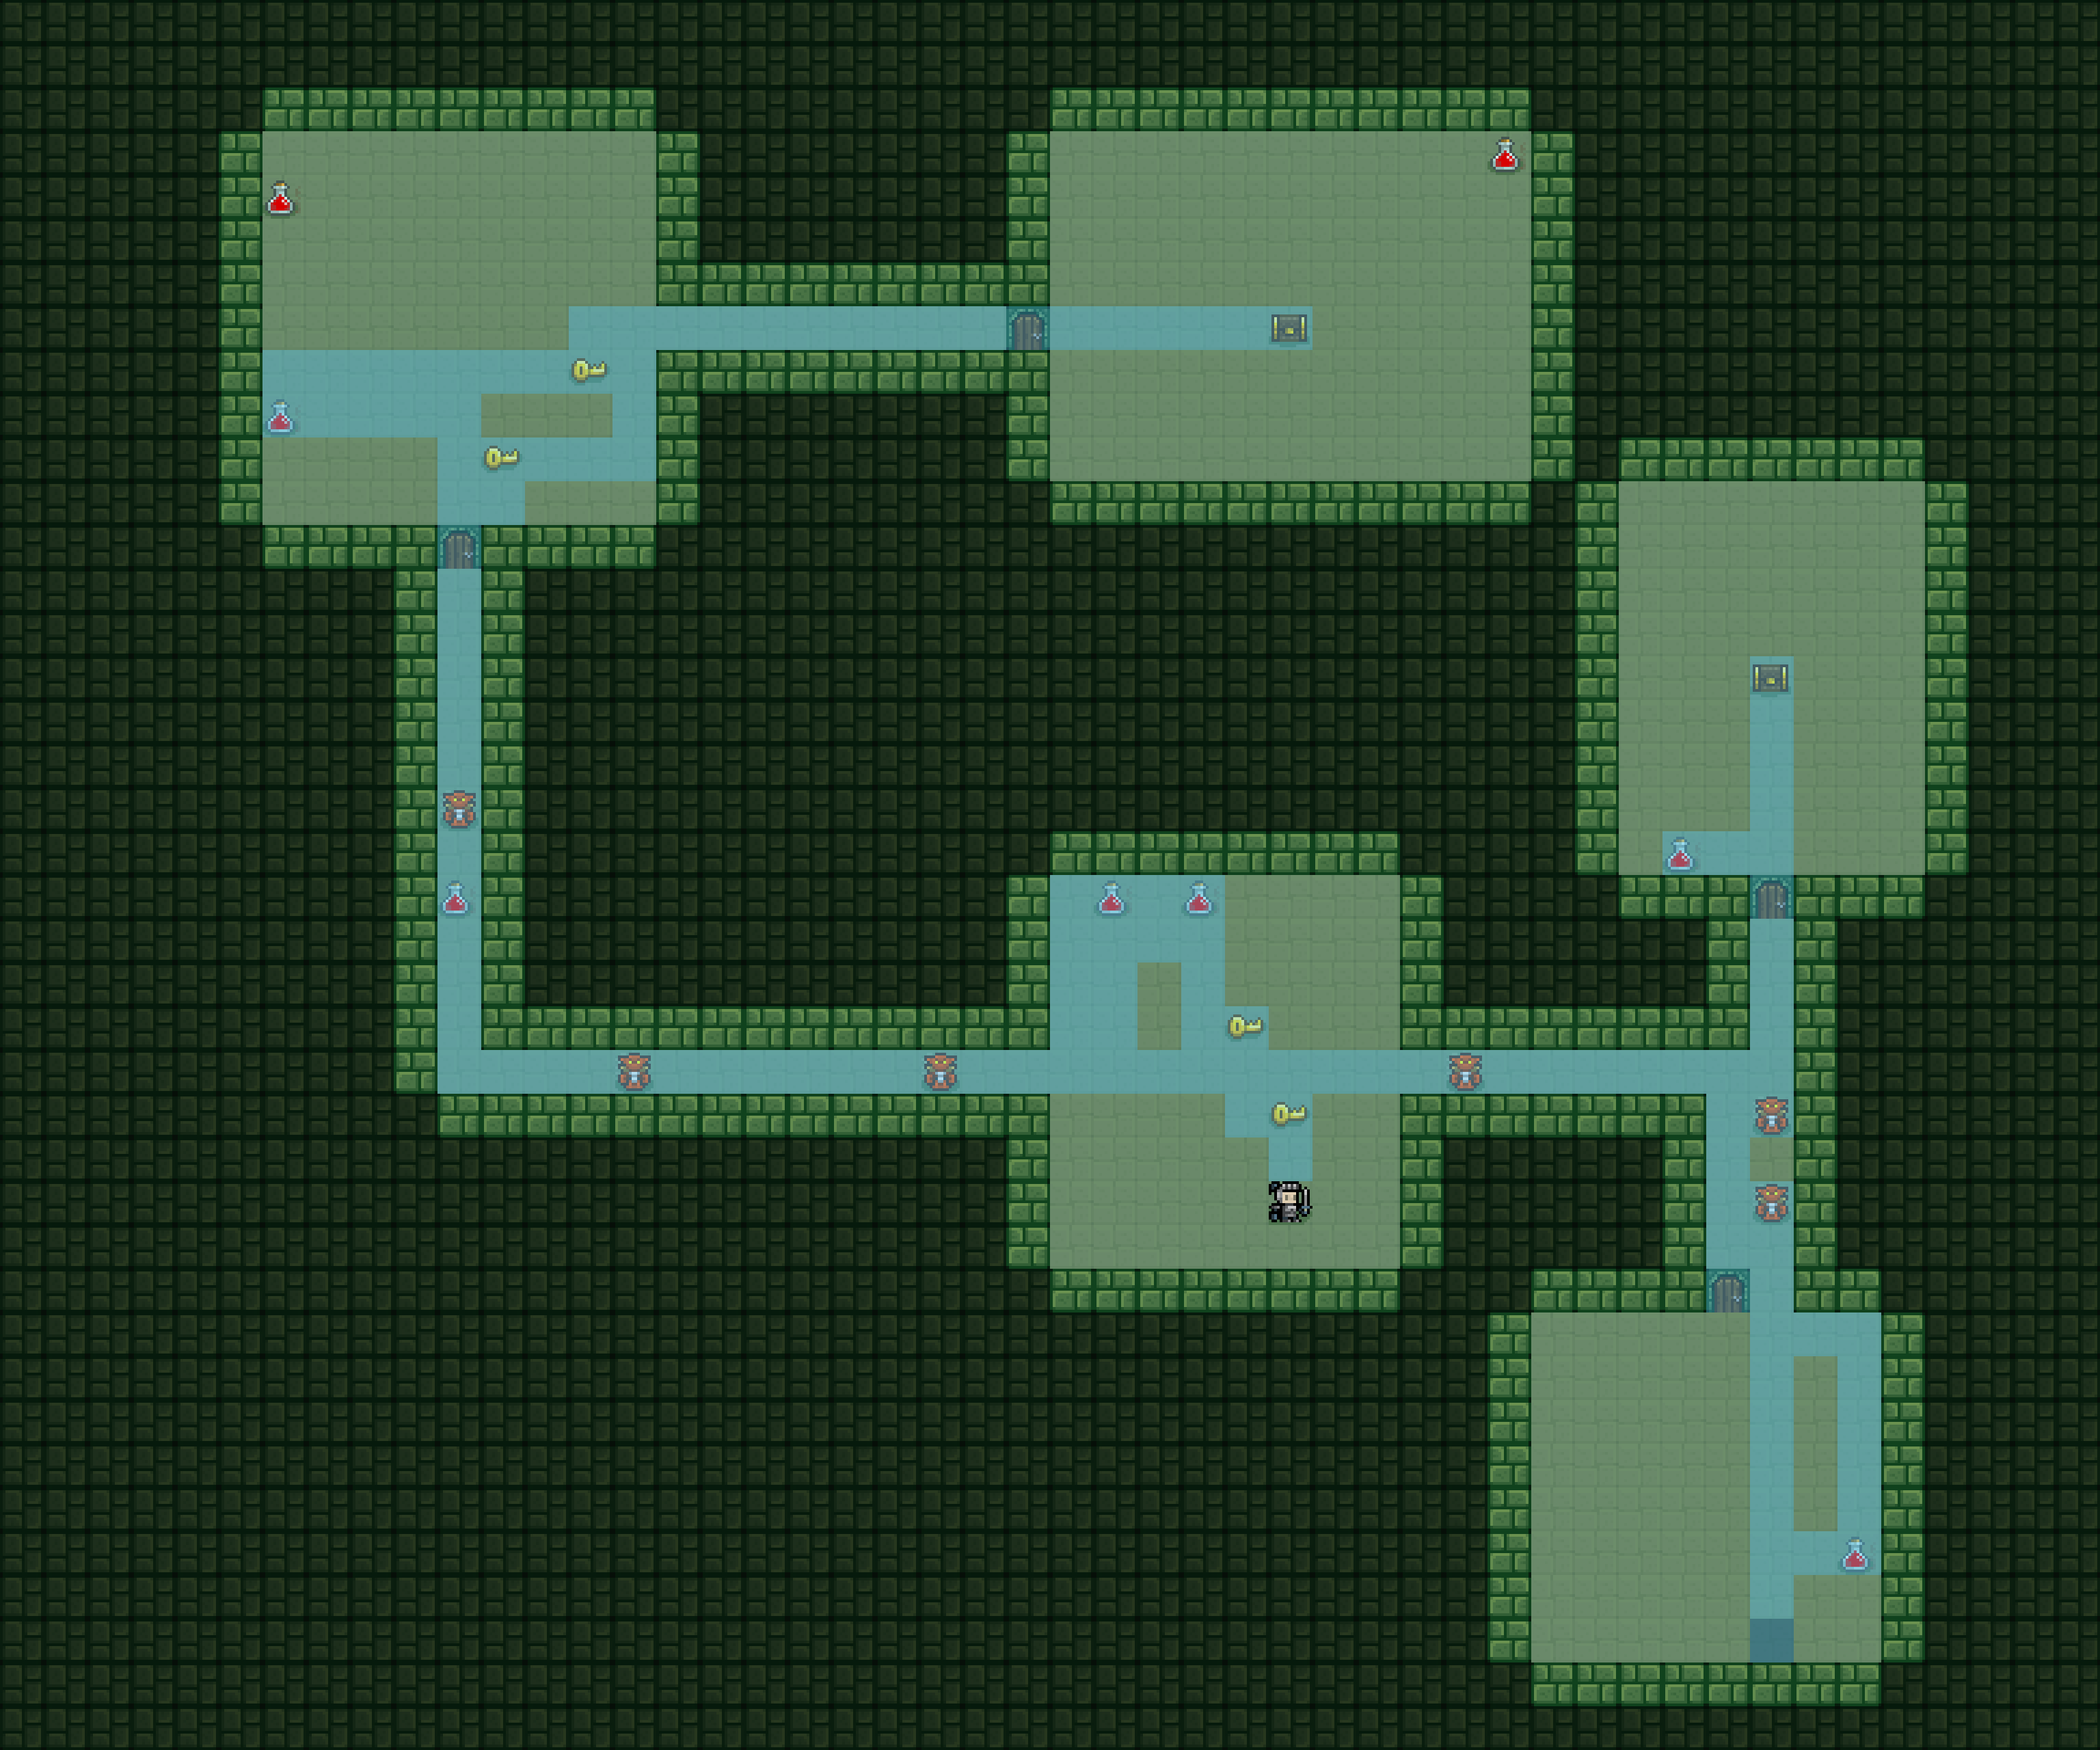

In [3]:
from IPython.display import display, Markdown, Image as IPyImage

dm2, cam2 = pcg.generate_until_valid(
    seed=CONFIG_EXTRA["seed_segundo_mapa"],
    width=pcg.DEMO_GENERATE_KWARGS["width"],
    height=pcg.DEMO_GENERATE_KWARGS["height"],
    n_rooms=pcg.DEMO_GENERATE_KWARGS["n_rooms"],
    max_tries=CONFIG_EXTRA["max_tries_segundo"],
)

print("Seed 2:", CONFIG_EXTRA["seed_segundo_mapa"])
print(pcg.summarize(dm2), "\nPassos:", len(cam2))

out2 = ROOT / "assets" / "mapa_notebook_extra.png"
pcg.render_map(dm2, sprites, path_overlay=cam2, scale=4).save(out2)
display(Markdown(f"**PNG:** `{out2.name}`"))
display(IPyImage(filename=str(out2)))


## 5. Onde está o código-fonte

- **`dungeon_pcg.py`** — módulo com `DEMO_GENERATE_KWARGS`, `generate_demo_map()`, construtor, BFS (`validate_dungeon`), render; a CLI chama `generate_demo_map()` e grava `assets/mapa_aprovado_demo.png`.
- **`requirements.txt`** — `Pillow`, `jupyter` (kernel Python com `ipykernel`).

**Linha de comandos (mesmo resultado que o `__main__`):**
```bash
cd "caminho/para/jogos v1"
python3 dungeon_pcg.py
```

**Algoritmo de busca:** BFS em largura; estado inclui máscaras de portas/chaves/poções/monstros/tesouros e **`may_fight`** (poção obrigatória antes de **cada** monstro).

**Tiles da folha (referência):** 1.ª linha: `(0,0)` parede limiar, `(1,0)` porta, **`(2,0)` fundo VOID não andável**; última célula `(2,2)` piso.